In [71]:
import os
import numpy as np
import matplotlib
from tqdm import tqdm

from data_loader import load_masked_channel_data_jp2
from model import (
    create_cluster_mask,
    detect_anomalies_isolation_forest,
    perform_kmeans_clustering
)
from preprocess import prepare_data_concatenated
from visualization import plot_results

# --- Default Configuration ---
# --- Default Configuration ---
config = {
    "data_dir": r"D:\OneDrive - Universidad de La Salle\Maestría IA\SOLAR\API\app\api\pipeline\testing_input",
    "output_dir": "./output_figures",
    "file_type": "jp2",  
    "channels": None,  # or list of channels like ['94', '131', '171']
    "image_size": 2048,
    "jp2_mask_radius": 1600,

    # --- Algorithm Parameters ---
    "anomaly_thresholds": [-0.1, 0.0, 0.1],
    "contamination": 0.02,
    "n_clusters": 5,
    "random_state": 42,

}




print("Step 0: Creating output directory...")
os.makedirs(config["output_dir"], exist_ok=True)

print("Step 1: Loading and preprocessing masked channel data...")
masked_data_list, channel_names, jp2_paths = load_masked_channel_data_jp2(
    config["data_dir"],
    config["image_size"]
)


print("Step 2: Preparing data for anomaly detection...")
prepared_data, valid_pixel_mask_1d, nan_mask_1d = prepare_data_concatenated(masked_data_list)


print("Step 3: Running Isolation Forest for anomaly detection...")
anomaly_scores = detect_anomalies_isolation_forest(
    prepared_data,config["contamination"])

print(f"Anomaly scores shape: {anomaly_scores.shape}")

# Create anomaly map
anomaly_map_2d = np.full((config["image_size"], config["image_size"]), np.nan)
valid_pixel_mask_1d = valid_pixel_mask_1d.astype(bool)
valid_pixel_mask_2d = valid_pixel_mask_1d.reshape((config["image_size"], config["image_size"]))
anomaly_map_2d[valid_pixel_mask_2d] = anomaly_scores
print(f"Anomaly map shape: {anomaly_map_2d.shape}, Non-NaN: {np.sum(~np.isnan(anomaly_map_2d))}")

total_pixels_resized = config["image_size"] * config["image_size"]

print("Step 4: Thresholding anomalies and clustering...")

for anomaly_threshold in config["anomaly_thresholds"]:
    print(f"\n===== Processing with Anomaly Threshold: {anomaly_threshold} =====")

    anomaly_mask_global_2d = np.full((config["image_size"], config["image_size"]), False)
    valid_score_mask = ~np.isnan(anomaly_map_2d)
    anomaly_mask_global_2d[valid_score_mask] = (anomaly_map_2d[valid_score_mask] < anomaly_threshold)

    anomaly_pixels_count = np.sum(anomaly_mask_global_2d)
    anomaly_percentage = (anomaly_pixels_count / np.sum(valid_score_mask)) * 100 if np.sum(valid_score_mask) > 0 else 0

    print(f"Anomalous pixels: {anomaly_pixels_count} ({anomaly_percentage:.2f}%)")

    valid_and_anomalous_mask_2d = valid_pixel_mask_2d & anomaly_mask_global_2d
    valid_and_anomalous_indices_flat = np.where(valid_and_anomalous_mask_2d.flatten())[0]

    full_indices = np.arange(total_pixels_resized)
    prepared_data_indices = np.full(total_pixels_resized, -1, dtype=int)
    prepared_data_indices[valid_pixel_mask_1d] = np.arange(prepared_data.shape[0])
    indices_for_clustering = prepared_data_indices[valid_and_anomalous_indices_flat]
    indices_for_clustering = indices_for_clustering[indices_for_clustering != -1]

    if len(indices_for_clustering) == 0:
        print("No anomalous pixels for clustering.")
        anomaly_intensity_features = np.array([])
    else:
        anomaly_intensity_features = prepared_data[indices_for_clustering]

    print(f"Data for clustering shape: {anomaly_intensity_features.shape}")

    cluster_labels = np.array([])
    cluster_mask_final = np.zeros((config["image_size"], config["image_size"]), dtype=int)
    cluster_cmap_final = matplotlib.colors.ListedColormap([])
    cluster_patches_final = []
    n_clusters_final = 0
    cluster_pixels_counts = []
    cluster_anomaly_percentages = []

    if anomaly_intensity_features.shape[0] >= config["n_clusters"]:
        cluster_labels, _ = perform_kmeans_clustering(
            anomaly_intensity_features, config["n_clusters"], config["random_state"]
        )

        cluster_mask_final, cluster_cmap_final, cluster_patches_final, n_clusters_final = create_cluster_mask(
            anomaly_mask_global_2d,
            cluster_labels,
            valid_pixel_mask_1d,
            config["image_size"]
        )

        if n_clusters_final > 0:
            for cluster_index in range(1, n_clusters_final + 1):
                count = np.sum(cluster_mask_final == cluster_index)
                pct = (count / anomaly_pixels_count) * 100 if anomaly_pixels_count > 0 else 0
                cluster_pixels_counts.append(count)
                cluster_anomaly_percentages.append(pct)
                print(f"  Cluster {cluster_index}: {count} pixels ({pct:.2f}%)")

    elif anomaly_intensity_features.shape[0] > 0:
        print(f"Not enough anomalies ({anomaly_intensity_features.shape[0]}) for {config['n_clusters']} clusters.")
    else:
        print("No data points for clustering.")

    print("    Saving visualizations...")

    # plot_results(
    #     masked_data_list,
    #     cluster_mask_final,
    #     cluster_cmap_final,
    #     n_clusters_final,
    #     cluster_patches_final,
    #     channel_names,
    #     anomaly_threshold,
    #     config["output_dir"]
    # )



Step 0: Creating output directory...
Step 1: Loading and preprocessing masked channel data...
Attempting to load JP2 with Imageio: D:\OneDrive - Universidad de La Salle\Maestría IA\SOLAR\API\app\api\pipeline\testing_input\2025_05_01__00_00_23_121__SDO_AIA_AIA_94.jp2
  Loaded shape: (4096, 4096), dtype: uint8
Creating JP2 mask for image size 4096x4096 using fixed radius: 256
  Generated JP2 mask shape: (4096, 4096), Sum: 205861
Preprocessing: Resizing data ((4096, 4096)) and mask ((4096, 4096)) to 2048x2048
  Resized mask shape: (2048, 2048), Sum: 51359
  Final masked data shape: (2048, 2048), Non-NaN count: 51359
Attempting to load JP2 with Imageio: D:\OneDrive - Universidad de La Salle\Maestría IA\SOLAR\API\app\api\pipeline\testing_input\2025_05_02__00_00_05_130__SDO_AIA_AIA_304.jp2
  Loaded shape: (4096, 4096), dtype: uint8
Creating JP2 mask for image size 4096x4096 using fixed radius: 256
  Generated JP2 mask shape: (4096, 4096), Sum: 205861
Preprocessing: Resizing data ((4096, 4096

Colormap sdoaia94 not found, using viridis.
Colormap sdoaia304 not found, using viridis.
Colormap sdoaia171 not found, using viridis.
Colormap sdoaia193 not found, using viridis.
Colormap sdoaia131 not found, using viridis.
Colormap sdoaia211 not found, using viridis.


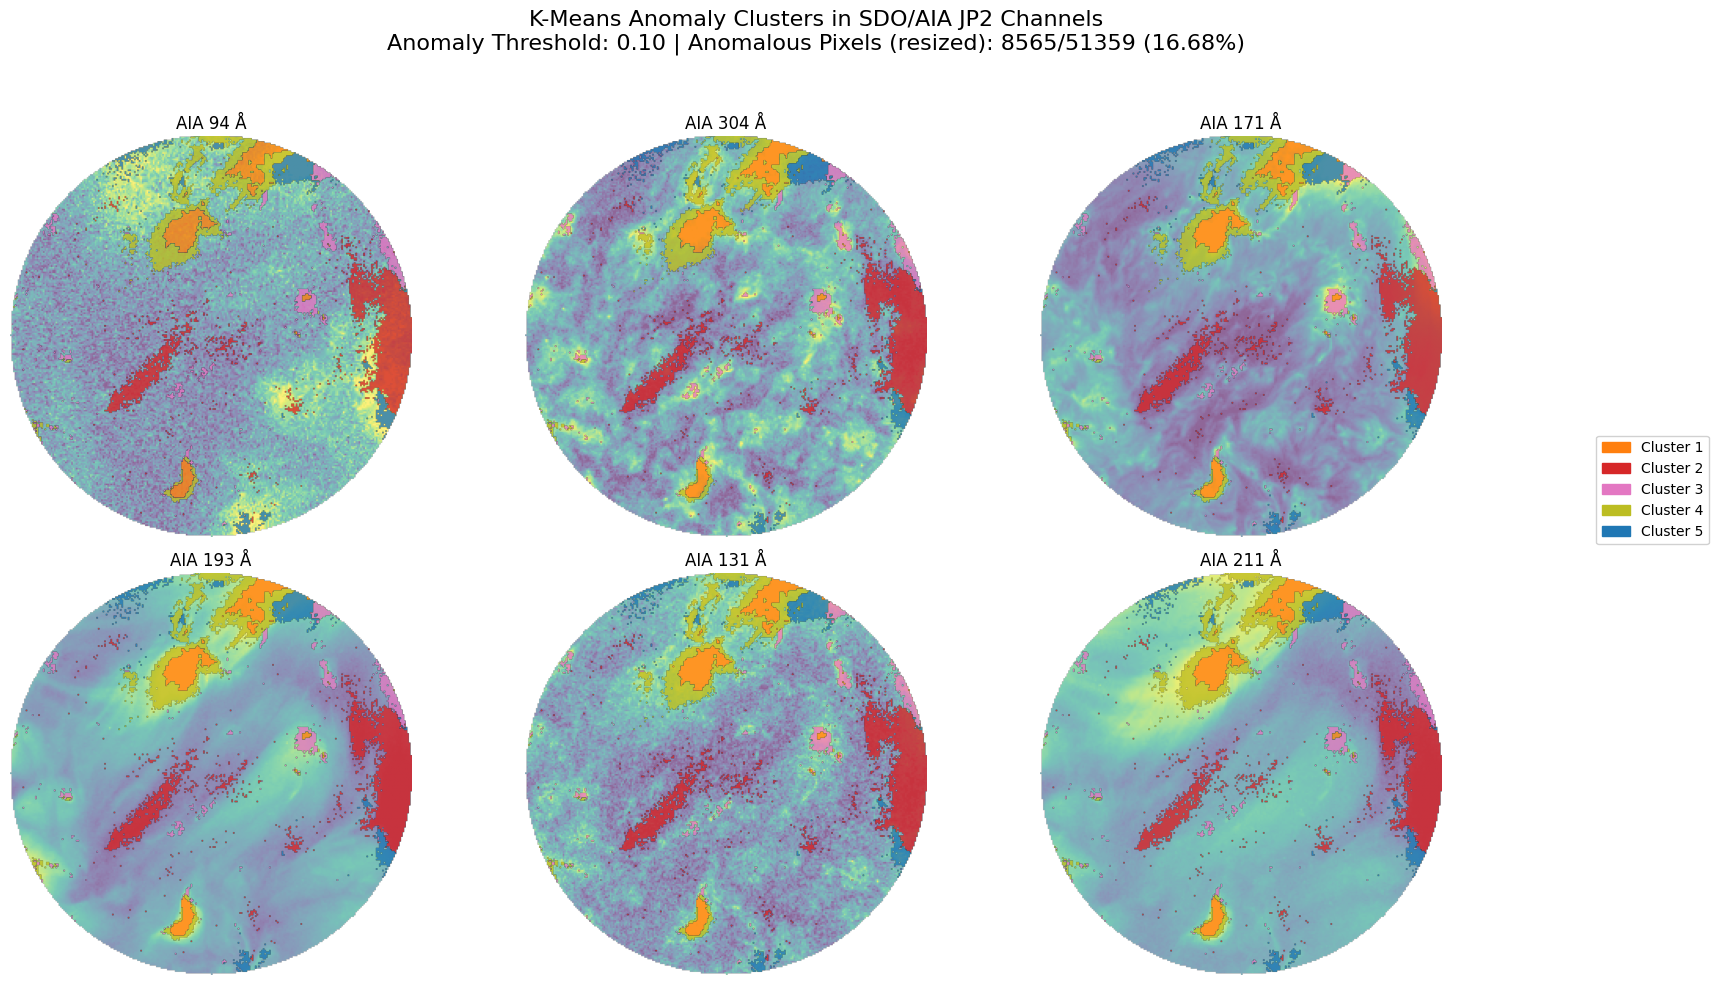

In [72]:
import os
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np


def crop_nan_array(masked_data, cluster_mask=None):
    """Recorta la imagen hasta el primer píxel no NaN por cada lado, sin perder los píxeles del cluster."""
    # Encuentra las filas y columnas que contienen valores no NaN
    valid_rows = ~np.isnan(masked_data).all(axis=1)  # Fila no completamente NaN
    valid_cols = ~np.isnan(masked_data).all(axis=0)  # Columna no completamente NaN
    
    # Si se proporciona la máscara de clusters, no recortamos las zonas del cluster
    if cluster_mask is not None:
        valid_rows = valid_rows | np.any(cluster_mask, axis=1)
        valid_cols = valid_cols | np.any(cluster_mask, axis=0)

    # Encuentra los índices de la primera y última fila válida
    min_row, max_row = np.where(valid_rows)[0][[0, -1]]
    
    # Encuentra los índices de la primera y última columna válida
    min_col, max_col = np.where(valid_cols)[0][[0, -1]]
    
    # Recortar la imagen según estos índices
    cropped_data = masked_data[min_row:max_row+1, min_col:max_col+1]
    
    # Recortar también la máscara del cluster
    cropped_cluster_mask = cluster_mask[min_row:max_row+1, min_col:max_col+1] if cluster_mask is not None else None
    
    return cropped_data, cropped_cluster_mask, (min_row, max_row, min_col, max_col)


def plot_results(
    masked_data_list: list,
    cluster_mask_global: np.ndarray,
    cluster_cmap_global: matplotlib.colors.ListedColormap,
    n_clusters_global: int,
    cluster_patches_global: list,
    channel_names: list,
    anomaly_threshold: float,
    output_dir: str,
    total_pixels_resized: int,
    anomaly_pixels_count: int,
    file_type: str,
    clustering_method_name: str = "K-Means",
):
    """Plots and saves anomaly detection and clustering results."""
    if not masked_data_list:
        print("No data to plot.")
        return

    # Determine plot grid size dynamically (e.g., up to 3x3)
    num_images = len(masked_data_list)
    num_cols = min(3, num_images)
    num_rows = (num_images + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 5 * num_rows), dpi=100, squeeze=False)  # Use squeeze=False for consistent 2D array
    axes = axes.flatten()

    anomaly_percentage = (anomaly_pixels_count / total_pixels_resized) * 100 if total_pixels_resized > 0 else 0
    fig.suptitle(
        f'{clustering_method_name} Anomaly Clusters in SDO/AIA {file_type.upper()} Channels\n'
        f'Anomaly Threshold: {anomaly_threshold:.2f} | Anomalous Pixels (resized): {anomaly_pixels_count}/{total_pixels_resized} ({anomaly_percentage:.2f}%)',
        fontsize=16, y=0.98 if num_rows > 1 else 1.02  # Adjust title position
    )

    base_cmap_name = 'sdoaia{channel}'  # Base colormap name template
    fallback_cmap = 'viridis'  # Fallback if specific AIA map isn't found

    for i, (masked_data, channel) in enumerate(zip(masked_data_list, channel_names)):
        if i >= len(axes): continue  # Should not happen with dynamic grid, but safe check

        ax = axes[i]

        # Recortar la imagen y la máscara del cluster
        cropped_data, cropped_cluster_mask, _ = crop_nan_array(masked_data, cluster_mask_global)

        # Try channel-specific colormap, else fallback
        try:
            cmap_name = base_cmap_name.format(channel=channel)
            img_cmap = plt.get_cmap(cmap_name)
        except ValueError:
            print(f"Colormap {cmap_name} not found, using {fallback_cmap}.")
            img_cmap = fallback_cmap

        # Plot base image (masked data)
        # Handle cases where all data might be NaN
        valid_data = cropped_data[~np.isnan(cropped_data)]
        if valid_data.size > 0:
             vmin = np.percentile(valid_data, 2)
             vmax = np.percentile(valid_data, 98)
        else:
             vmin, vmax = 0, 1  # Default if no valid data

        ax.imshow(
            cropped_data, cmap=img_cmap, origin='lower',
            vmin=vmin, vmax=vmax,
            alpha=0.6  # Slightly more transparent base
        )

        # Overlay clusters if they exist
        if n_clusters_global > 0 and cropped_cluster_mask is not None:
            # Plot each cluster individually to control color and legend precisely
            for cluster_index in range(1, n_clusters_global + 1):
                cluster_area_mask = (cropped_cluster_mask == cluster_index)
                if np.any(cluster_area_mask):  # Only plot if pixels exist for this cluster
                    # Use the provided global cmap, ensure index is correct
                    # cmap expects normalized value 0..1
                    cluster_color_norm = (cluster_index - 1) / (n_clusters_global - 1 if n_clusters_global > 1 else 1)
                    cluster_color = cluster_cmap_global(cluster_color_norm)
                    # Create a single-color map for this cluster
                    single_color_cmap = matplotlib.colors.ListedColormap([cluster_color])

                    # Mask everything *except* the current cluster
                    overlay = np.ma.masked_where(~cluster_area_mask, cropped_cluster_mask)
                    ax.imshow(
                        overlay,
                        cmap=single_color_cmap,  # Use the single color map
                        origin='lower',
                        alpha=0.8,  # Make clusters slightly more opaque
                        vmin=cluster_index - 0.5, vmax=cluster_index + 0.5  # Center vmin/vmax on index
                    )

        # Set title
        title_lines = [f'AIA {channel} Å']
        ax.set_title("\n".join(title_lines), color='black', fontsize=12, pad=5)  # Slightly smaller font
        ax.axis('off')

    # Add legend if clusters were found
    if cluster_patches_global:
        # Place legend outside the plot area to avoid overlap
        fig.legend(
            handles=cluster_patches_global,
            loc='center right',  # Position relative to the figure
            bbox_to_anchor=(1.0, 0.5),  # Adjust anchor to be outside
            fontsize='medium',  # Slightly larger legend font
            framealpha=0.9
        )

    # Remove empty subplots
    for j in range(num_images, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Adjust rect to make space for legend if needed
    filename = os.path.join(
        output_dir, f"{file_type}_kmeans_anomaly_detection_thresh_{anomaly_threshold:.2f}.png"  # Updated filename
    )
    plt.show()

plot_results(
    masked_data_list=masked_data_list,
    cluster_mask_global=cluster_mask_final,
    cluster_cmap_global=cluster_cmap_final,
    n_clusters_global=n_clusters_final,
    cluster_patches_global=cluster_patches_final,
    channel_names=channel_names,
    anomaly_threshold=anomaly_threshold,
    output_dir=config["output_dir"],
    total_pixels_resized=np.sum(valid_score_mask), # Base total on valid pixels in resized img
    anomaly_pixels_count=anomaly_pixels_count,
    file_type=config["file_type"], # Pass file type for filename/title
    clustering_method_name="K-Means"
)



Colormap sdoaia94 not found, using viridis.
Colormap sdoaia304 not found, using viridis.
Colormap sdoaia171 not found, using viridis.
Colormap sdoaia193 not found, using viridis.
Colormap sdoaia131 not found, using viridis.
Colormap sdoaia211 not found, using viridis.


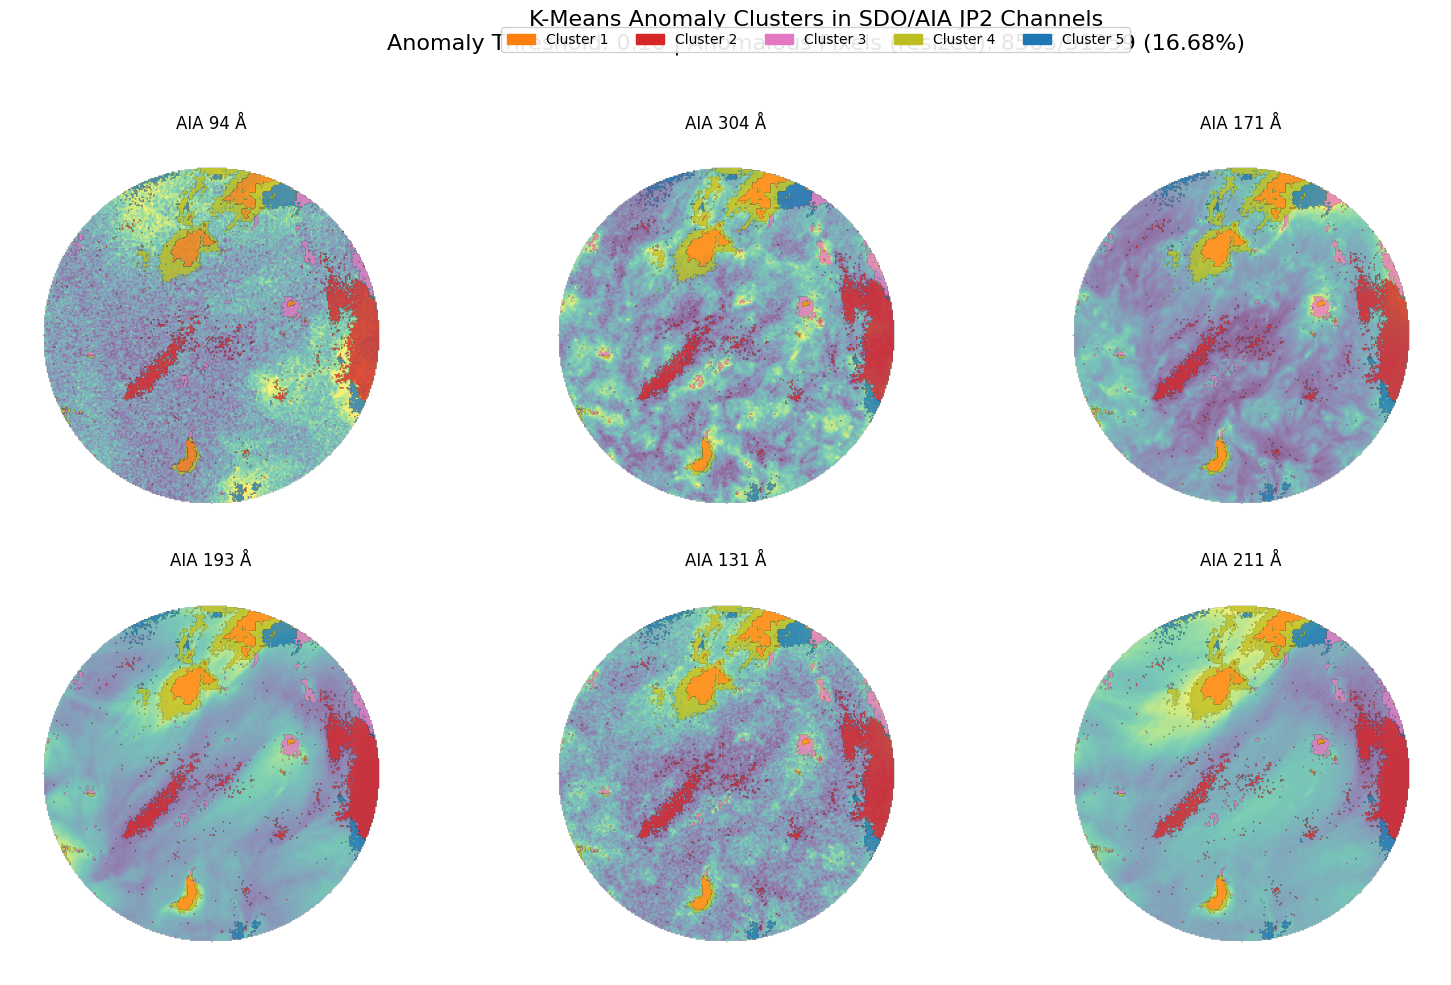

In [79]:
def plot_results(
    masked_data_list: list,
    cluster_mask_global: np.ndarray,
    cluster_cmap_global: matplotlib.colors.ListedColormap,
    n_clusters_global: int,
    cluster_patches_global: list,
    channel_names: list,
    anomaly_threshold: float,
    output_dir: str,
    total_pixels_resized: int,
    anomaly_pixels_count: int,
    file_type: str,
    clustering_method_name: str = "K-Means",
):
    """Plots and saves anomaly detection and clustering results."""
    if not masked_data_list:
        print("No data to plot.")
        return

    # Determine plot grid size dynamically (e.g., up to 3x3)
    num_images = len(masked_data_list)
    num_cols = min(3, num_images)
    num_rows = (num_images + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 5 * num_rows), dpi=100, squeeze=False)  # Use squeeze=False for consistent 2D array
    axes = axes.flatten()

    anomaly_percentage = (anomaly_pixels_count / total_pixels_resized) * 100 if total_pixels_resized > 0 else 0
    fig.suptitle(
        f'{clustering_method_name} Anomaly Clusters in SDO/AIA {file_type.upper()} Channels\n'
        f'Anomaly Threshold: {anomaly_threshold:.2f} | Anomalous Pixels (resized): {anomaly_pixels_count}/{total_pixels_resized} ({anomaly_percentage:.2f}%)',
        fontsize=16, y=0.98 if num_rows > 1 else 1.02  # Adjust title position
    )

    base_cmap_name = 'sdoaia{channel}'  # Base colormap name template
    fallback_cmap = 'viridis'  # Fallback if specific AIA map isn't found

    for i, (masked_data, channel) in enumerate(zip(masked_data_list, channel_names)):
        if i >= len(axes): continue  # Should not happen with dynamic grid, but safe check

        ax = axes[i]

        # Recortar la imagen y la máscara del cluster con margen
        cropped_data, cropped_cluster_mask, _ = crop_with_margin(masked_data, cluster_mask_global)

        # Try channel-specific colormap, else fallback
        try:
            cmap_name = base_cmap_name.format(channel=channel)
            img_cmap = plt.get_cmap(cmap_name)
        except ValueError:
            print(f"Colormap {cmap_name} not found, using {fallback_cmap}.")
            img_cmap = fallback_cmap

        # Plot base image (masked data)
        # Handle cases where all data might be NaN
        valid_data = cropped_data[~np.isnan(cropped_data)]
        if valid_data.size > 0:
             vmin = np.percentile(valid_data, 2)
             vmax = np.percentile(valid_data, 98)
        else:
             vmin, vmax = 0, 1  # Default if no valid data

        ax.imshow(
            cropped_data, cmap=img_cmap, origin='lower',
            vmin=vmin, vmax=vmax,
            alpha=0.6  # Slightly more transparent base
        )

        # Overlay clusters if they exist
        if n_clusters_global > 0 and cropped_cluster_mask is not None:
            # Plot each cluster individually to control color and legend precisely
            for cluster_index in range(1, n_clusters_global + 1):
                cluster_area_mask = (cropped_cluster_mask == cluster_index)
                if np.any(cluster_area_mask):  # Only plot if pixels exist for this cluster
                    # Use the provided global cmap, ensure index is correct
                    # cmap expects normalized value 0..1
                    cluster_color_norm = (cluster_index - 1) / (n_clusters_global - 1 if n_clusters_global > 1 else 1)
                    cluster_color = cluster_cmap_global(cluster_color_norm)
                    # Create a single-color map for this cluster
                    single_color_cmap = matplotlib.colors.ListedColormap([cluster_color])

                    # Mask everything *except* the current cluster
                    overlay = np.ma.masked_where(~cluster_area_mask, cropped_cluster_mask)
                    ax.imshow(
                        overlay,
                        cmap=single_color_cmap,  # Use the single color map
                        origin='lower',
                        alpha=0.8,  # Make clusters slightly more opaque
                        vmin=cluster_index - 0.5, vmax=cluster_index + 0.5  # Center vmin/vmax on index
                    )

        # Set title
        title_lines = [f'AIA {channel} Å']
        ax.set_title("\n".join(title_lines), color='black', fontsize=12, pad=5)  # Slightly smaller font
        ax.axis('off')

    # Add legend below the title, centered
    if cluster_patches_global:
        fig.legend(
            handles=cluster_patches_global,
            loc='upper center',  # Position relative to the figure
            bbox_to_anchor=(0.5, 0.97),  # Just below the title
            fontsize='medium',  # Slightly larger legend font
            framealpha=0.9,
            ncol=len(cluster_patches_global),  # Place in multiple columns if needed
        )

    # Remove empty subplots
    for j in range(num_images, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Adjust rect to make space for legend if needed
    filename = os.path.join(
        output_dir, f"{file_type}_kmeans_anomaly_detection_thresh_{anomaly_threshold:.2f}.png"  # Updated filename
    )

    plt.show()

plot_results(
    masked_data_list=masked_data_list,
    cluster_mask_global=cluster_mask_final,
    cluster_cmap_global=cluster_cmap_final,
    n_clusters_global=n_clusters_final,
    cluster_patches_global=cluster_patches_final,
    channel_names=channel_names,
    anomaly_threshold=anomaly_threshold,
    output_dir=config["output_dir"],
    total_pixels_resized=np.sum(valid_score_mask), # Base total on valid pixels in resized img
    anomaly_pixels_count=anomaly_pixels_count,
    file_type=config["file_type"], # Pass file type for filename/title
    clustering_method_name="K-Means"
)
